In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# **Paths Setup**

In [3]:
DATA_DIR = "/kaggle/input/indian-currency-real-vs-fake-notes-dataset/data/data"
BASE_MODEL_PATH = "/kaggle/input/best_fake_curruncy_branch1/keras/default/1/best_model.h5"
SAVE_PATH = "/kaggle/working/fine_tuned_base_model.keras"


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# **Load and Preprocess Dataset**

In [4]:
def load_images(folder, label):
    images, labels = [], []
    for subdir in os.listdir(folder):
        sub_path = os.path.join(folder, subdir)
        if not os.path.isdir(sub_path):
            continue
        for file in tqdm(os.listdir(sub_path), desc=f"Loading {subdir}"):
            img_path = os.path.join(sub_path, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, IMG_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

real_imgs, real_lbls = load_images(os.path.join(DATA_DIR, "real"), 1)
fake_imgs, fake_lbls = load_images(os.path.join(DATA_DIR, "fake"), 0)

X = np.concatenate([real_imgs, fake_imgs])
y = np.concatenate([real_lbls, fake_lbls])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)
print(f"Dataset ready: Train={len(X_train)} | Validation={len(X_val)}")

Loading 100: 100%|██████████| 380/380 [00:03<00:00, 106.35it/s]


Dataset ready: Train=5956 | Validation=1489


# **Create TensorFlow Datasets**

In [5]:
def make_dataset(images, labels, train=True):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32)/255.0, tf.cast(y, tf.int32)),
                num_parallel_calls=tf.data.AUTOTUNE)
    if train:
        ds = ds.shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    else:
        ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train)
val_ds = make_dataset(X_val, y_val, train=False)

I0000 00:00:1760778383.884032      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1760778383.884899      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# **Load Pretrained Model**

In [6]:
# Fix Lambda deserialization issue (safe_mode=False)
tf.keras.config.enable_unsafe_deserialization()

try:
    base_model = load_model(BASE_MODEL_PATH, compile=False, safe_mode=False)
    print("Model loaded successfully with unsafe deserialization enabled.")
except Exception as e:
    print("Normal load failed, trying alternative method:", e)
    base_model = tf.keras.models.load_model(BASE_MODEL_PATH, compile=False)


Model loaded successfully with unsafe deserialization enabled.


In [7]:
base_model.trainable = True

# **Unfreeze Deeper Layers for Fine-Tuning**

In [8]:
fine_tune_at = 100  # unfreeze from this layer index

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# **Compile Model with Low LR**

In [9]:
base_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# **Callbacks**

In [10]:
callbacks = [
    EarlyStopping(patience=4, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=2),
    ModelCheckpoint(SAVE_PATH, save_best_only=True)
]

# **Fine-Tune Model**

In [11]:
history = base_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10


I0000 00:00:1760778516.491324      98 service.cc:148] XLA service 0x7e84901111a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760778516.493117      98 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1760778516.493149      98 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1760778517.681183      98 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/187 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 1.0000 - loss: 0.0068 

I0000 00:00:1760778525.173154      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


187/187 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.9896 - loss: 0.0336 - val_accuracy: 0.9946 - val_loss: 0.0142 - learning_rate: 1.0000e-05
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.9938 - loss: 0.0164 - val_accuracy: 0.9966 - val_loss: 0.0087 - learning_rate: 1.0000e-05
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9970 - loss: 0.0099 - val_accuracy: 0.9940 - val_loss: 0.0127 - learning_rate: 1.0000e-05
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9961 - loss: 0.0091 - val_accuracy: 0.9973 - val_loss: 0.0113 - learning_rate: 1.0000e-05
Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9989 - loss: 0.0042 - val_accuracy: 0.9960 - val_loss: 0.0067 - learning_rate: 2.0000e-06
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9990 - loss: 0.0034 - val_accuracy: 0.9973 - val_loss: 0.0057 - learning_rate: 2.0000e-06
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.

# **Save Final Fine-Tuned Model**

In [12]:
base_model.save(SAVE_PATH)

# **Plot Accuracy and Loss**

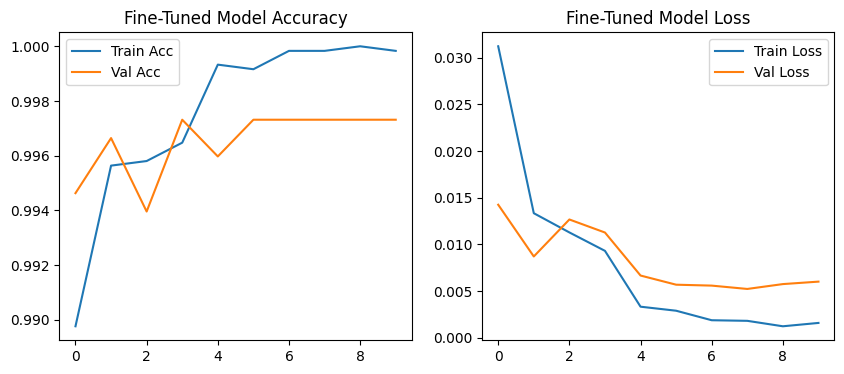

In [13]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Fine-Tuned Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Fine-Tuned Model Loss')
plt.legend()
plt.show()